
# Accident Detection from CCTV — EfficientNetB0 Transfer Learning

This version replaces the CNN trained from scratch with **EfficientNetB0 pretrained on ImageNet**.

Key fixes:
- Uses the dataset's real `train`, `val`, and `test` folders.
- Uses 224×224 input instead of 128×128.
- Streams images with `image_dataset_from_directory` instead of loading everything into RAM.
- Uses realistic training augmentation.
- Uses class weights to avoid the model collapsing to the majority `Non Accident` class.
- Trains in two stages: frozen backbone → gentle fine-tuning.
- Reports accuracy, precision, recall, F1, confusion matrix, and ROC-AUC.


## 1. Download the dataset

In [ ]:
!pip install -q kagglehub tensorflow opencv-python-headless scikit-learn seaborn

In [1]:

import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import kagglehub

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

path = kagglehub.dataset_download("ckay16/accident-detection-from-cctv-footage")
print("Dataset path:", path)


100%|██████████| 249M/249M [00:01<00:00, 148MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1


## 2. Locate train / validation / test folders

In [2]:

def find_split_dirs(root):
    splits = {}
    for dirpath, dirnames, _ in os.walk(root):
        for d in dirnames:
            key = d.lower()
            if key in ("train", "training"):
                splits["train"] = os.path.join(dirpath, d)
            elif key in ("test", "testing"):
                splits["test"] = os.path.join(dirpath, d)
            elif key in ("val", "valid", "validation"):
                splits["val"] = os.path.join(dirpath, d)
    return splits

split_dirs = find_split_dirs(path)
print("Splits found:", split_dirs)

train_dir = split_dirs["train"]
val_dir = split_dirs.get("val")
test_dir = split_dirs.get("test")

assert val_dir is not None, "A validation directory was not found."
assert test_dir is not None, "A test directory was not found."

CLASS_NAMES = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])
CLASS_TO_LABEL = {name: i for i, name in enumerate(CLASS_NAMES)}
print("Classes:", CLASS_TO_LABEL)


Splits found: {'val': '/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/val', 'test': '/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/test', 'train': '/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/train'}
Classes: {'Accident': 0, 'Non Accident': 1}


## 3. Dataset statistics

Train {'Accident': 369, 'Non Accident': 422}
Validation {'Accident': 46, 'Non Accident': 52}
Test {'Accident': 47, 'Non Accident': 53}


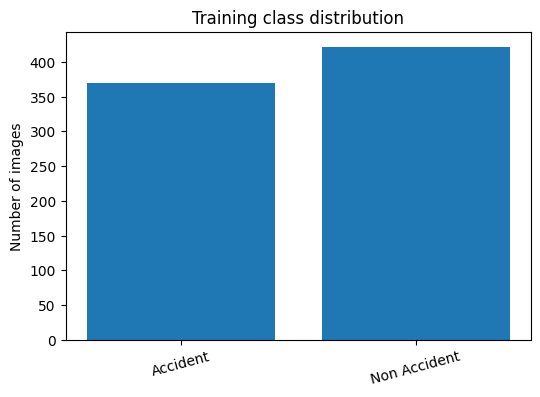

In [3]:

def count_images(folder):
    counts = {}
    for class_name in CLASS_NAMES:
        class_dir = os.path.join(folder, class_name)
        counts[class_name] = sum(
            f.lower().endswith((".jpg", ".jpeg", ".png"))
            for f in os.listdir(class_dir)
        )
    return counts

for name, folder in [("Train", train_dir), ("Validation", val_dir), ("Test", test_dir)]:
    print(name, count_images(folder))

train_counts = count_images(train_dir)
plt.figure(figsize=(6,4))
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training class distribution")
plt.ylabel("Number of images")
plt.xticks(rotation=15)
plt.show()


## 4. Build streaming TensorFlow datasets

In [4]:

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# EfficientNetB0 in tf.keras includes its input rescaling.
# Keep image pixels in the normal [0, 255] range here.
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


Found 791 files belonging to 2 classes.
Found 98 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


## 5. Visualize training samples

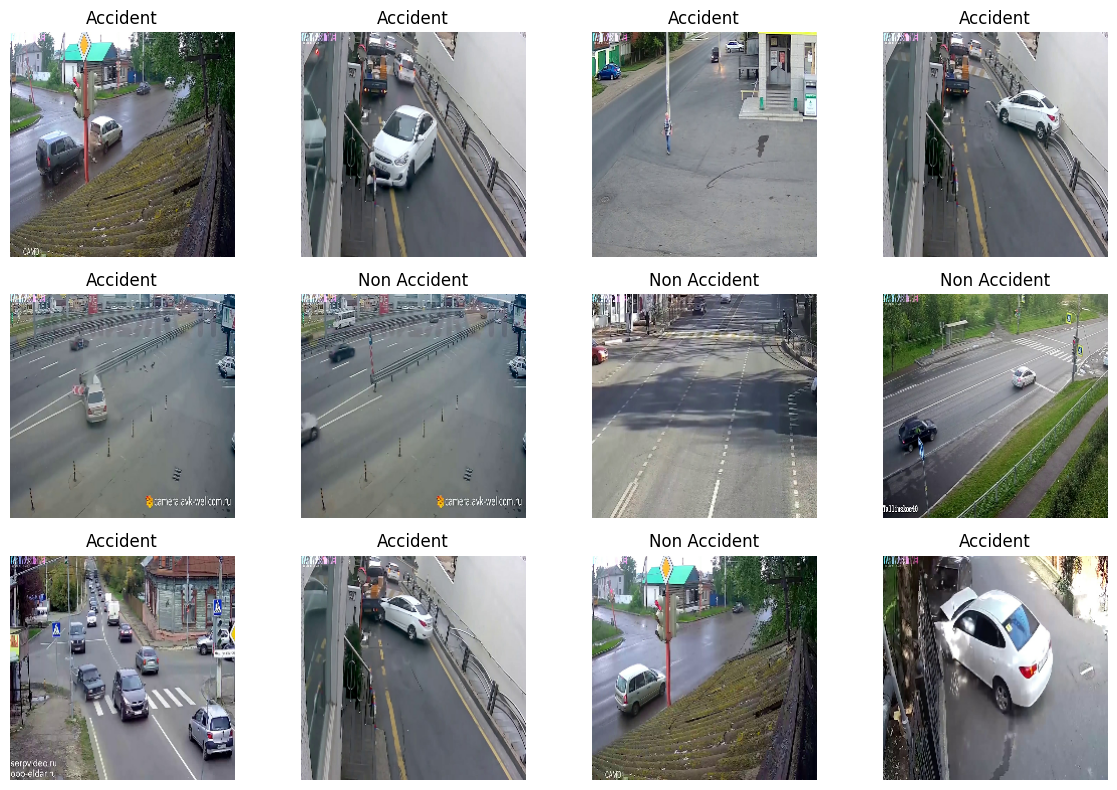

In [5]:

plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()


## 6. Augmentation and class weights

In [6]:

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.04),
    keras.layers.RandomZoom(0.08),
    keras.layers.RandomTranslation(0.04, 0.04),
    keras.layers.RandomContrast(0.10),
], name="data_augmentation")

# Balanced class weights: total / (number_of_classes × samples_in_class)
total = sum(train_counts.values())
num_classes = len(CLASS_NAMES)
class_weight = {
    CLASS_TO_LABEL[name]: total / (num_classes * count)
    for name, count in train_counts.items()
}
print("Class weights:", class_weight)


Class weights: {0: 1.0718157181571815, 1: 0.9372037914691943}


## 7. Build EfficientNetB0

In [7]:

base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, 3),
)
base_model.trainable = False

inputs = keras.Input(shape=(*IMAGE_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.35)(x)
x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dropout(0.25)(x)
outputs = keras.layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="accident_efficientnetb0")
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "accident_efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,917 (16.09 MB)

 Trainable params: 166,786 (651.51 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 8. Stage 1 — train the new classification head

In [8]:

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_stage1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
    ),
    keras.callbacks.ModelCheckpoint(
        "best_accident_efficientnet_stage1.keras",
        monitor="val_accuracy", save_best_only=True
    ),
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weight,
    callbacks=callbacks_stage1,
)


Epoch 1/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 175ms/step - accuracy: 0.5626 - loss: 1.1417 - val_accuracy: 0.5714 - val_loss: 0.6361 - learning_rate: 3.0000e-04
Epoch 2/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.6549 - loss: 0.7748 - val_accuracy: 0.6939 - val_loss: 0.5638 - learning_rate: 3.0000e-04
Epoch 3/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.7181 - loss: 0.6633 - val_accuracy: 0.7041 - val_loss: 0.5397 - learning_rate: 3.0000e-04
Epoch 4/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.6941 - loss: 0.6736 - val_accuracy: 0.7245 - val_loss: 0.4883 - learning_rate: 3.0000e-04
Epoch 5/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.7168 - loss: 0.5875 - val_accuracy: 0.7551 - val_loss: 0.4368 - learning_rate: 3.0000e-04
Epoch 6/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.7497 - loss: 0.5883 - val_accuracy: 0.8163 - val_loss: 0.3999 - learning_rate: 3.0000e-04
Epoch 7/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 

## 9. Stage 2 — fine-tune the top of EfficientNet

In [9]:

# Unfreeze only the upper ~30% of EfficientNet layers.
# BatchNorm layers stay frozen because the dataset is small.
base_model.trainable = True
fine_tune_from = int(len(base_model.layers) * 0.70)

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_from:]:
    layer.trainable = not isinstance(layer, keras.layers.BatchNormalization)

trainable_count = sum(layer.trainable for layer in base_model.layers)
print(f"Trainable EfficientNet layers: {trainable_count}/{len(base_model.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_stage2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        "best_accident_efficientnet.keras",
        monitor="val_accuracy", save_best_only=True
    ),
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=18,
    class_weight=class_weight,
    callbacks=callbacks_stage2,
)


Trainable EfficientNet layers: 57/238
Epoch 1/18
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 156ms/step - accuracy: 0.7901 - loss: 0.4590 - val_accuracy: 0.8265 - val_loss: 0.3259 - learning_rate: 1.0000e-05
Epoch 2/18
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.7977 - loss: 0.4678 - val_accuracy: 0.8367 - val_loss: 0.3182 - learning_rate: 1.0000e-05
Epoch 3/18
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - accuracy: 0.7737 - loss: 0.4791 - val_accuracy: 0.8469 - val_loss: 0.3034 - learning_rate: 1.0000e-05
Epoch 4/18
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.7977 - loss: 0.4570 - val_accuracy: 0.8367 - val_loss: 0.3069 - learning_rate: 1.0000e-05
Epoch 5/18
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.8015 - loss: 0.4070 - val_accuracy: 0.8673 - val_loss: 0.2916 - learning_rate: 1.0000e-05
Epoch 6/18
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.7952 - loss: 0.4587 - val_accuracy: 0.8673 - val_loss: 0.2819 - learning_rate: 1.0000e-05
Epoch 7/18
50/50 ━━━━━━━━

## 10. Training curves

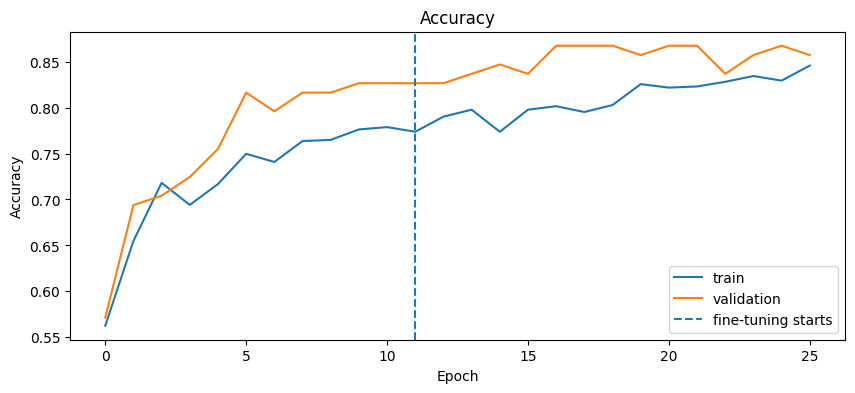

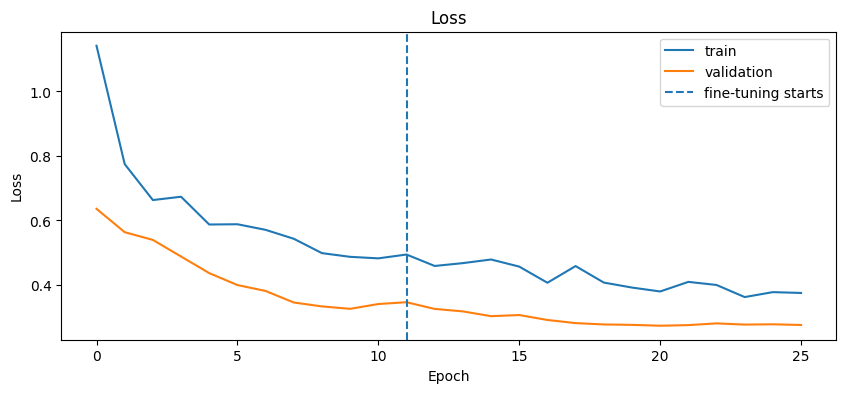

In [10]:

def combine_history(h1, h2):
    return {
        key: h1.history.get(key, []) + h2.history.get(key, [])
        for key in set(h1.history) | set(h2.history)
    }

history = combine_history(history1, history2)

plt.figure(figsize=(10,4))
plt.plot(history["accuracy"], label="train")
plt.plot(history["val_accuracy"], label="validation")
plt.axvline(len(history1.history["accuracy"]) - 1, linestyle="--", label="fine-tuning starts")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history["loss"], label="train")
plt.plot(history["val_loss"], label="validation")
plt.axvline(len(history1.history["loss"]) - 1, linestyle="--", label="fine-tuning starts")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.show()


## 11. Evaluate on the untouched test set

In [12]:

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss:     {test_loss:.4f}")

# Collect true labels and probabilities.
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification report:")
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    zero_division=0,
))

if num_classes == 2:
    auc = roc_auc_score(y_true, y_prob[:, 1])
    print(f"ROC-AUC: {auc:.4f}")


Test accuracy: 0.8800
Test loss:     0.2409

Classification report:
              precision    recall  f1-score   support

    Accident       0.89      0.85      0.87        47
Non Accident       0.87      0.91      0.89        53

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100

ROC-AUC: 0.9603


## 12. Confusion matrix

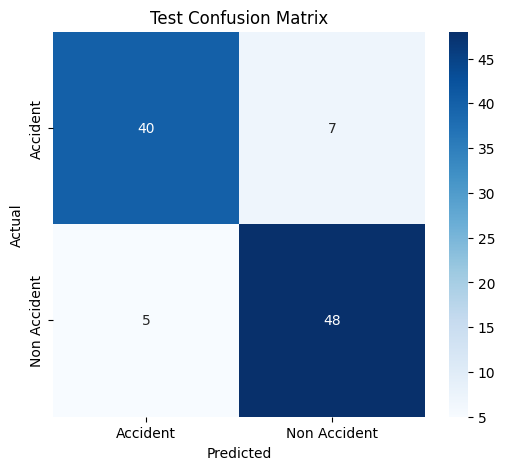

In [13]:

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Confusion Matrix")
plt.show()


## 13. ROC curve

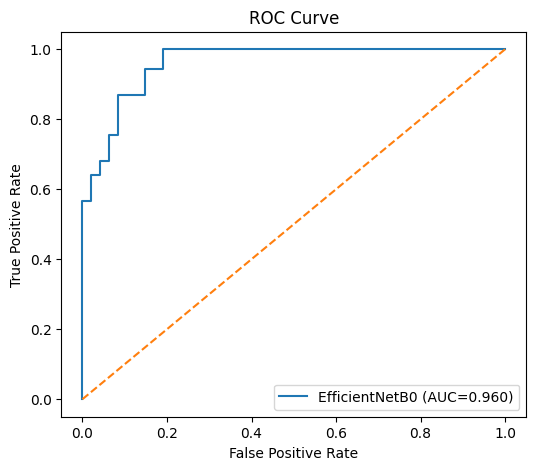

In [14]:

if num_classes == 2:
    fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
    auc = roc_auc_score(y_true, y_prob[:, 1])
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"EfficientNetB0 (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()


## 14. Multiple-image inference

In [21]:
import os

# Search for the Accident folder
matches = []

for root, dirs, files in os.walk("/"):
    # Avoid system folders that can cause unnecessary errors
    if any(x in root for x in ["/proc", "/sys", "/dev"]):
        continue

    if os.path.basename(root) == "Accident":
        image_files = [
            f for f in files
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        if image_files:
            matches.append((root, len(image_files)))

print("Found folders:")

for path, count in matches:
    print(f"{path}  -->  {count} images")

Found folders:
/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/val/Accident  -->  46 images
/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/test/Accident  -->  47 images
/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/train/Accident  -->  369 images


In [22]:
import os
import glob



TEST_DIR = "/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/test"


print("TEST_DIR:", TEST_DIR)

if TEST_DIR is None:
    print("❌ Test folder was not found.")
else:
    accident_images = glob.glob(
        os.path.join(TEST_DIR, "Accident", "*")
    )
    non_accident_images = glob.glob(
        os.path.join(TEST_DIR, "Non Accident", "*")
    )

    print("Number of accident images:", len(accident_images))

    if accident_images:
        print("First image:")
        print(accident_images[0])

TEST_DIR: /root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/test
Number of accident images: 47
First image:
/root/.cache/kagglehub/datasets/ckay16/accident-detection-from-cctv-footage/versions/1/data/test/Accident/test21_10.jpg


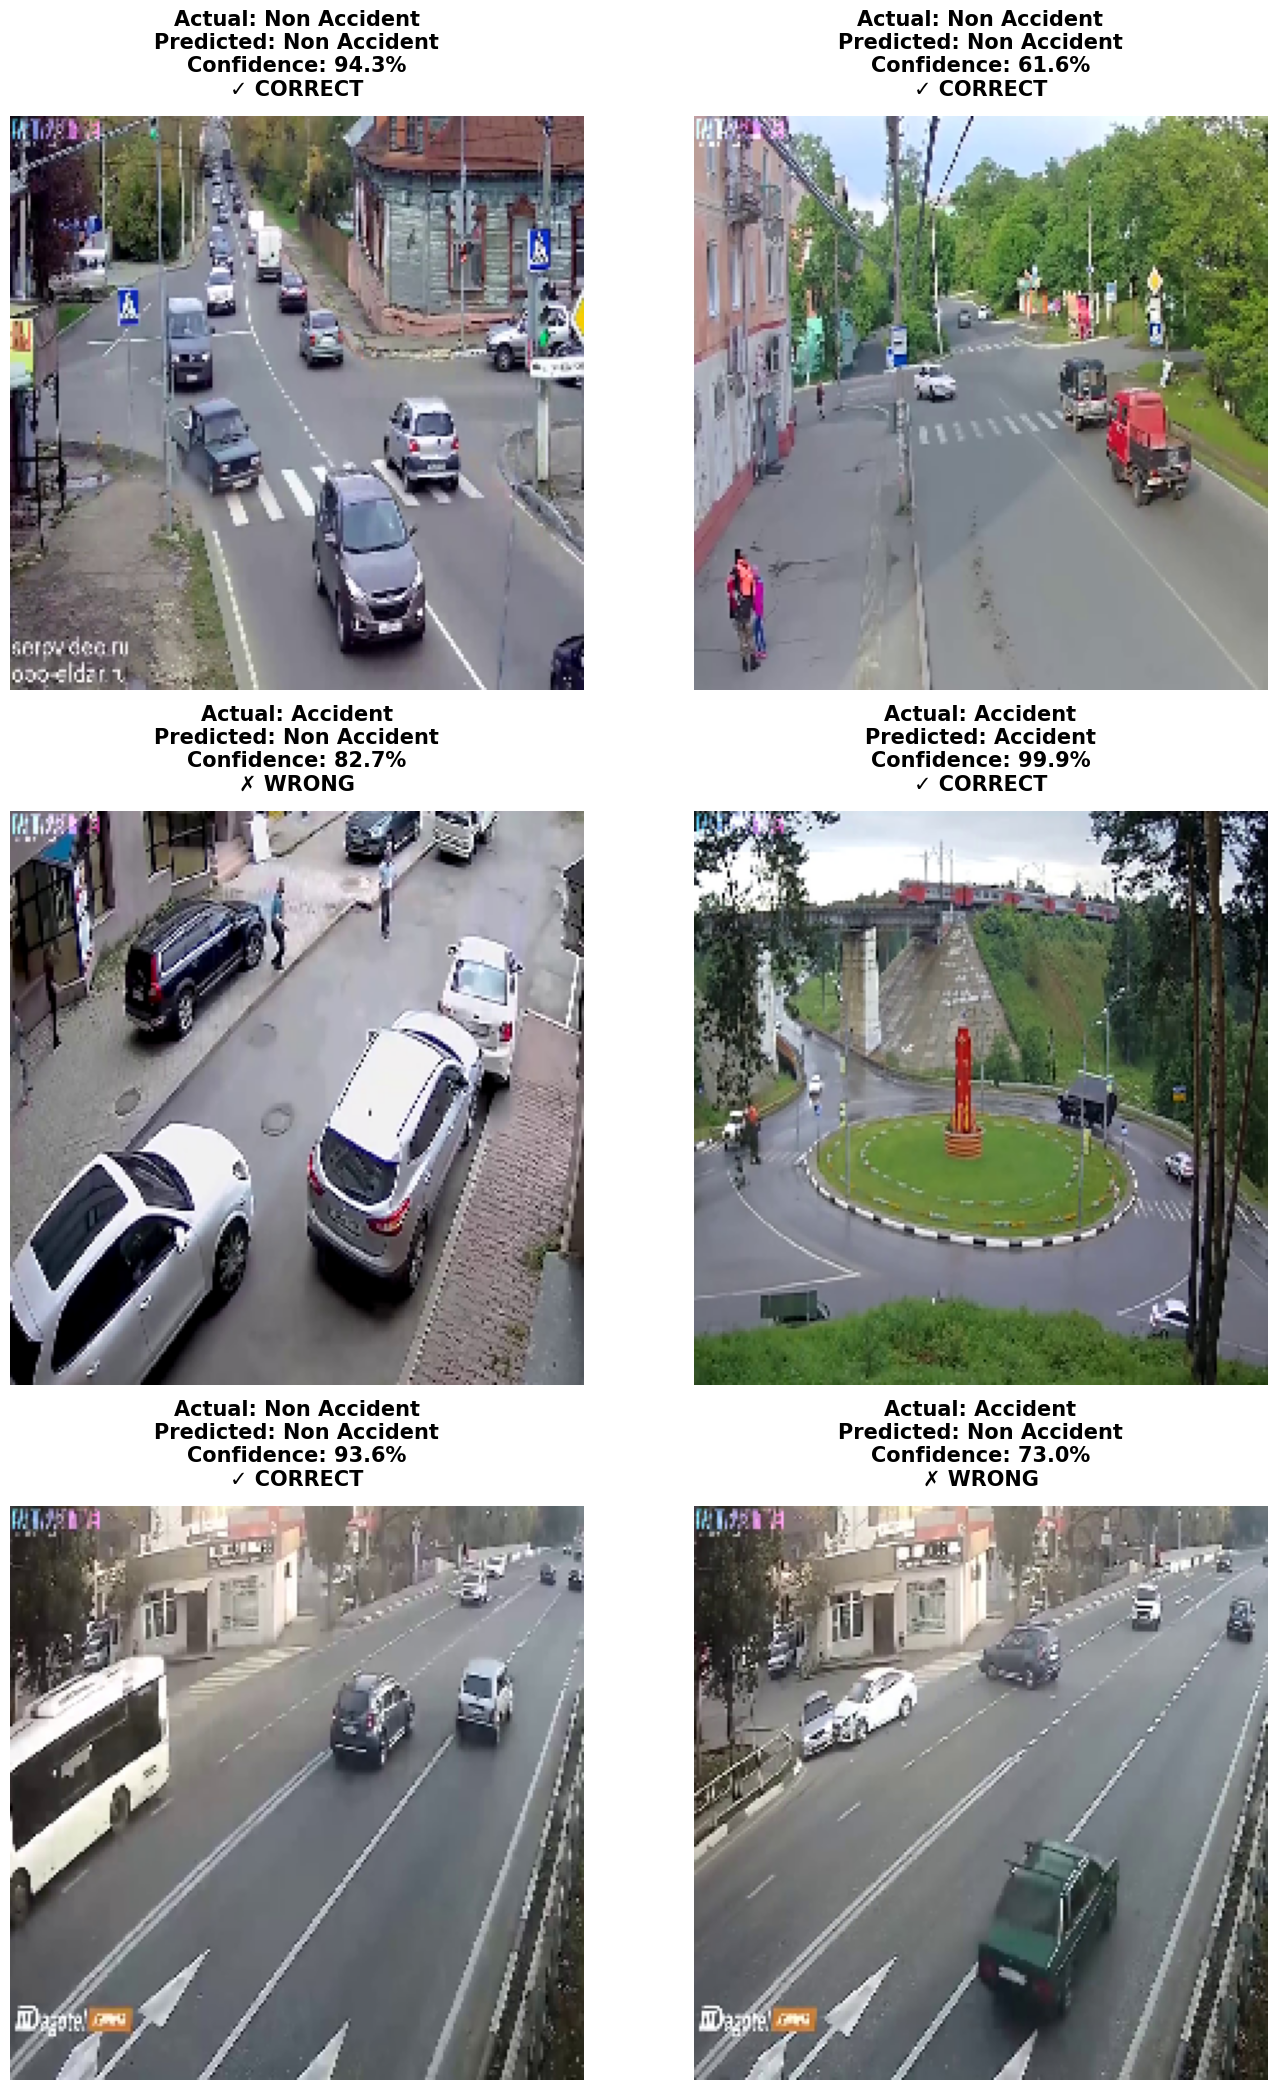

In [23]:
import os
import glob
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import math



num_images = 6

# Make sure we don't request more than available
num_images = min(
    num_images,
    len(accident_images) + len(non_accident_images)
)

# Select approximately half from each class
n_accident = num_images // 2
n_non_accident = num_images - n_accident

selected_accidents = random.sample(
    accident_images,
    min(n_accident, len(accident_images))
)

selected_non_accidents = random.sample(
    non_accident_images,
    min(n_non_accident, len(non_accident_images))
)

selected_images = selected_accidents + selected_non_accidents

# Shuffle
random.shuffle(selected_images)

# ---------------------------------------------------------
# 3. Create the EXACT number of axes needed
# ---------------------------------------------------------
cols = 2
rows = math.ceil(len(selected_images) / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(14, 7 * rows)
)

# Make axes always iterable
axes = np.array(axes).reshape(-1)

# ---------------------------------------------------------
# 4. Predict and display
# ---------------------------------------------------------
for i, filepath in enumerate(selected_images):

    # Load image
    image = tf.keras.utils.load_img(
        filepath,
        target_size=IMAGE_SIZE
    )

    image_array = tf.keras.utils.img_to_array(image)

    # Predict
    probs = model.predict(
        np.expand_dims(image_array, axis=0),
        verbose=0
    )[0]

    predicted_label = int(np.argmax(probs))
    predicted_class = CLASS_NAMES[predicted_label]
    confidence = probs[predicted_label]

    # Actual class
    actual_class = os.path.basename(
        os.path.dirname(filepath)
    )

    # Check correctness
    correct = predicted_class == actual_class

    # Display
    axes[i].imshow(image)
    axes[i].axis("off")

    axes[i].set_title(
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.1%}\n"
        f"{'✓ CORRECT' if correct else '✗ WRONG'}",
        fontsize=15,
        fontweight="bold",
        pad=15
    )

# Hide unused axes
for j in range(len(selected_images), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 15. Save the model

In [15]:
model.save("accident_detection_efficientnetb0.keras")
print("Saved model to accident_detection_efficientnetb0.keras")


Saved model to accident_detection_efficientnetb0.keras


## Alerting system

In [24]:
import smtplib
from email.message import EmailMessage


def send_accident_alert(
    sender_email,
    app_password,
    receiver_email,
    confidence
):
    msg = EmailMessage()

    msg["Subject"] = "🚨 ACCIDENT DETECTED!"
    msg["From"] = sender_email
    msg["To"] = receiver_email

    msg.set_content(
        f"""
🚨 ACCIDENT ALERT

The accident detection system detected a possible accident.

Confidence: {confidence:.2%}

Please check the camera footage immediately.
"""
    )

    with smtplib.SMTP_SSL("smtp.gmail.com", 465) as smtp:
        smtp.login(sender_email, app_password)
        smtp.send_message(msg)

    print("📧 Alert email sent successfully!")

In [32]:
def predict_and_alert(filepath):

    image = tf.keras.utils.load_img(
        filepath,
        target_size=IMAGE_SIZE
    )

    image_array = tf.keras.utils.img_to_array(image)

    probs = model.predict(
        np.expand_dims(image_array, axis=0),
        verbose=0
    )[0]

    predicted_label = int(np.argmax(probs))
    predicted_class = CLASS_NAMES[predicted_label]
    confidence = float(probs[predicted_label])

    print(f"Prediction: {predicted_class}")
    print(f"Confidence: {confidence:.2%}")

    # Send email only for high-confidence accidents
    if predicted_class == "Accident" and confidence >= 0.80:

        send_accident_alert(
    sender_email = "yaseenislam2005@gmail.com",
    app_password = "ziqzegislhcnqakv",
    receiver_email = 'ahmednasr6770164@gmail.com',
    confidence = confidence
        )


    else:
        print("✅ No alert sent.")

    return predicted_class, confidence

In [34]:
predict_and_alert(accident_images[3])

Prediction: Accident
Confidence: 98.83%
📧 Alert email sent successfully!


('Accident', 0.9883368611335754)